In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:

df = pd.read_csv('2019.csv')

In [29]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:")
df.head()

Shape: (156, 9)

Column Names:
 ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

Data Types:
 Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

First 5 Rows:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [30]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [31]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [32]:
print("\nBasic Stats:")
df.describe()


Basic Stats:


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [33]:
print(df.columns.tolist())
print("\nSample row:")
print(df.iloc[0])

['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

Sample row:
Overall rank                          1
Country or region               Finland
Score                             7.769
GDP per capita                     1.34
Social support                    1.587
Healthy life expectancy           0.986
Freedom to make life choices      0.596
Generosity                        0.153
Perceptions of corruption         0.393
Name: 0, dtype: object


In [34]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

print("Cleaned column names:")
print(df.columns.tolist())

print(summary)

Cleaned column names:
['overall_rank', 'country_or_region', 'score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']

Dataset Summary:
- 156 countries ranked by happiness score in 2019
- 9 columns covering economic, social, and personal freedom indicators
- No missing values or duplicates found
- Key numeric columns: score, gdp_per_capita, healthy_life_expectancy
- Data is ready for exploratory analysis without major cleaning



In [35]:
print("1: Top 10 Happiest Countries ")
print(df[['country_or_region', 'score']].head(10))

1: Top 10 Happiest Countries 
  country_or_region  score
0           Finland  7.769
1           Denmark  7.600
2            Norway  7.554
3           Iceland  7.494
4       Netherlands  7.488
5       Switzerland  7.480
6            Sweden  7.343
7       New Zealand  7.307
8            Canada  7.278
9           Austria  7.246


In [36]:
print(" 2: Bottom 10 Least Happy Countries ")
print(df[['country_or_region', 'score']].tail(10))

 2: Bottom 10 Least Happy Countries 
            country_or_region  score
146                     Haiti  3.597
147                  Botswana  3.488
148                     Syria  3.462
149                    Malawi  3.410
150                     Yemen  3.380
151                    Rwanda  3.334
152                  Tanzania  3.231
153               Afghanistan  3.203
154  Central African Republic  3.083
155               South Sudan  2.853


In [37]:
print("3: Correlation of Each Factor with Happiness Score ")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
correlations = df[numeric_cols].corr()['score'].sort_values(ascending=False)
print(correlations)

3: Correlation of Each Factor with Happiness Score 
score                           1.000000
gdp_per_capita                  0.793883
healthy_life_expectancy         0.779883
social_support                  0.777058
freedom_to_make_life_choices    0.566742
perceptions_of_corruption       0.385613
generosity                      0.075824
overall_rank                   -0.989096
Name: score, dtype: float64


In [38]:
print("4: Happiness Score Statistics ")
print(df['score'].describe())
print(f"\nAverage happiness score: {df['score'].mean():.2f}")
print(f"Happiest country score: {df['score'].max():.2f}")
print(f"Least happy country score: {df['score'].min():.2f}")

4: Happiness Score Statistics 
count    156.000000
mean       5.407096
std        1.113120
min        2.853000
25%        4.544500
50%        5.379500
75%        6.184500
max        7.769000
Name: score, dtype: float64

Average happiness score: 5.41
Happiest country score: 7.77
Least happy country score: 2.85


In [40]:
print("5: GDP vs Happiness - Top 20 vs Bottom 20 ")
top20_gdp = df.nlargest(20, 'gdp_per_capita')['score'].mean()
bottom20_gdp = df.nsmallest(20, 'gdp_per_capita')['score'].mean()
print(f"Avg happiness (Top 20 wealthy): {top20_gdp:.2f}")
print(f"Avg happiness (Bottom 20 wealthy): {bottom20_gdp:.2f}")
print(f"Difference: {top20_gdp - bottom20_gdp:.2f} points")

5: GDP vs Happiness - Top 20 vs Bottom 20 
Avg happiness (Top 20 wealthy): 6.92
Avg happiness (Bottom 20 wealthy): 4.03
Difference: 2.89 points


/tmp/ipykernel_3960/2611667043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='country_or_region', data=top10, palette='YlGn')


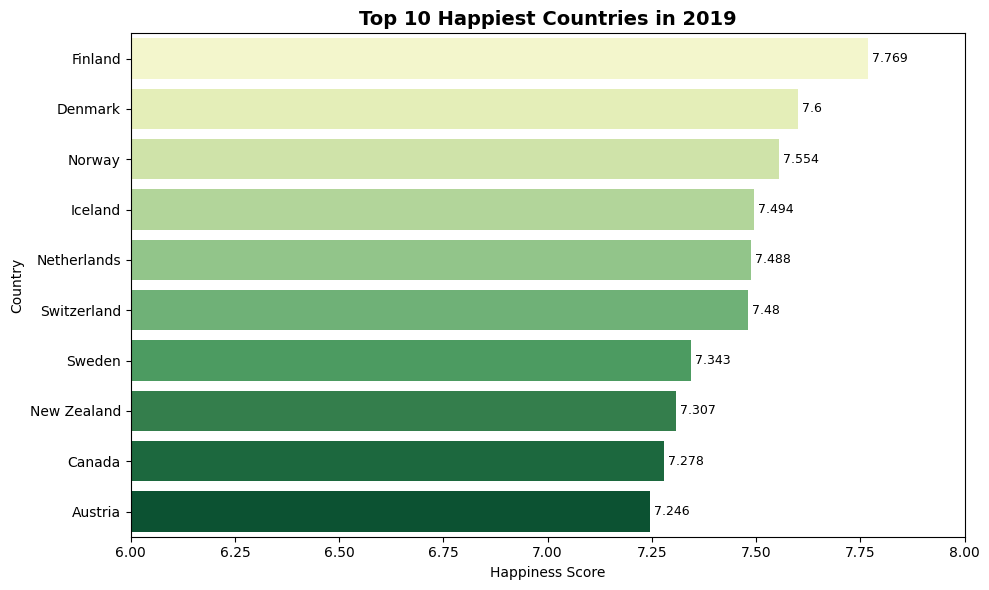

In [41]:
# Bar Chart
plt.figure(figsize=(10, 6))
top10 = df.nlargest(10, 'score')
sns.barplot(x='score', y='country_or_region', data=top10, palette='YlGn')
plt.title('Top 10 Happiest Countries in 2019', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.xlim(6, 8)
for i, v in enumerate(top10['score']):
    plt.text(v + 0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

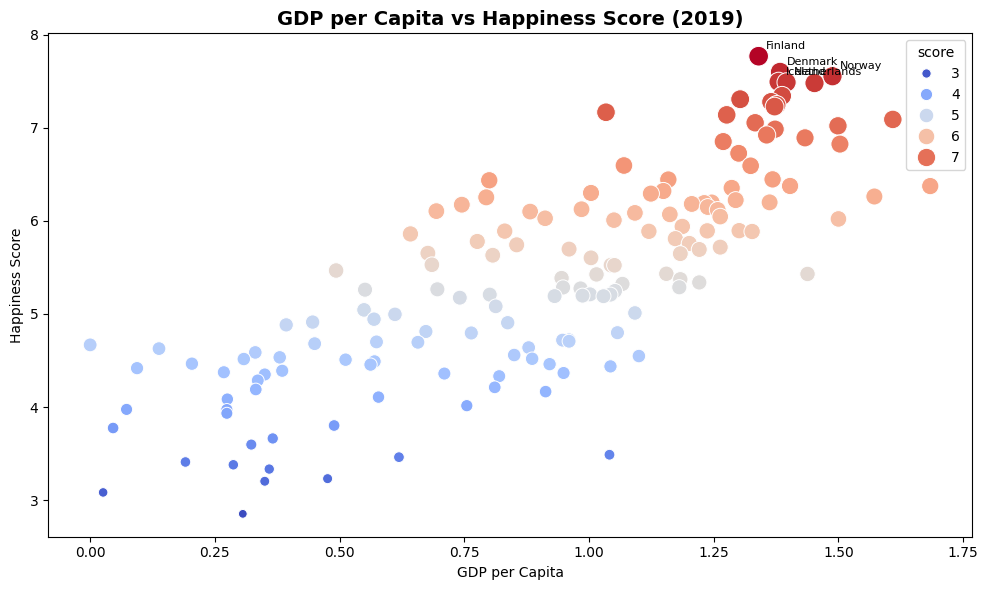

In [44]:
#Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='gdp_per_capita', y='score', data=df,
                hue='score', palette='coolwarm', size='score', sizes=(40, 200))

# Label top 5 countries
for i, row in df.nlargest(5, 'score').iterrows():
    plt.annotate(row['country_or_region'],
                 (row['gdp_per_capita'], row['score']),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.title('GDP per Capita vs Happiness Score (2019)', fontsize=14, fontweight='bold')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

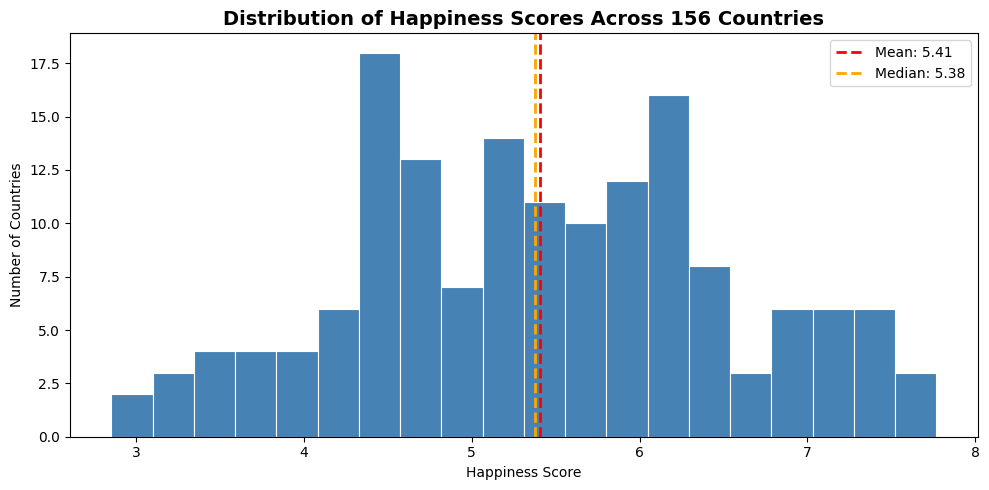

In [48]:
#histgram
plt.figure(figsize=(10, 5))
plt.hist(df['score'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
plt.axvline(df['score'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['score'].mean():.2f}")
plt.axvline(df['score'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['score'].median():.2f}")
plt.title('Distribution of Happiness Scores Across 156 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score')
plt.ylabel('Number of Countries')
plt.legend()
plt.tight_layout()
plt.show()

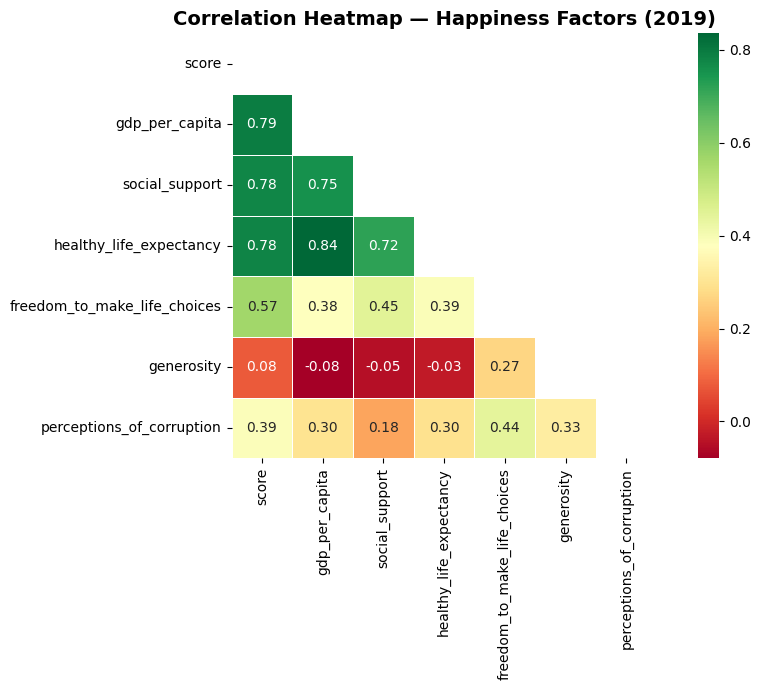

In [49]:
#heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number).drop(columns=['overall_rank'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Happiness Factors (2019)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

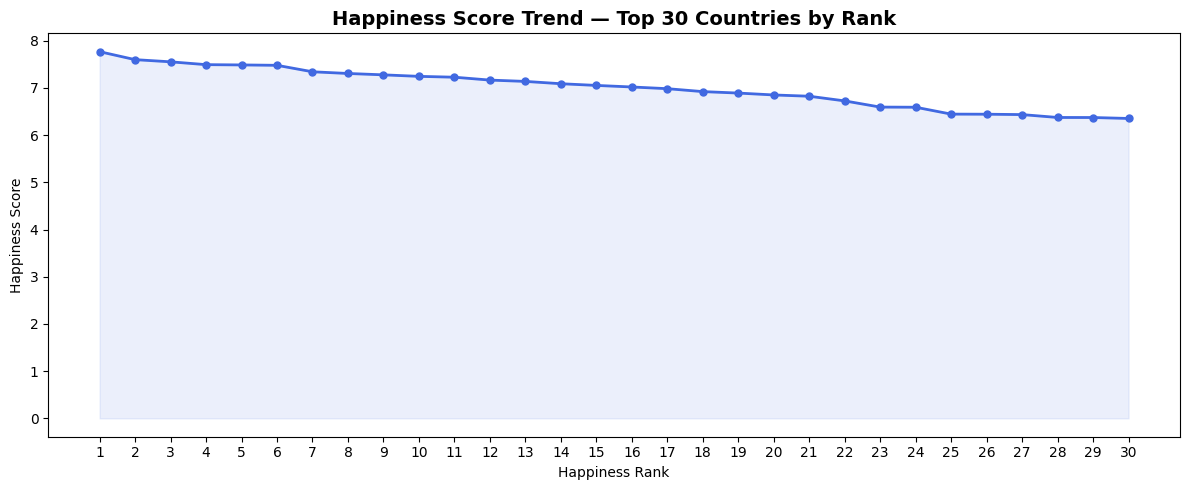

In [52]:
#Line chart
plt.figure(figsize=(12, 5))
top30 = df.nsmallest(30, 'overall_rank')
plt.plot(top30['overall_rank'], top30['score'], marker='o',
         color='royalblue', linewidth=2, markersize=5)
plt.fill_between(top30['overall_rank'], top30['score'], alpha=0.1, color='royalblue')
plt.title('Happiness Score Trend — Top 30 Countries by Rank', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Rank')
plt.ylabel('Happiness Score')
plt.xticks(top30['overall_rank'])
plt.tight_layout()
plt.show()

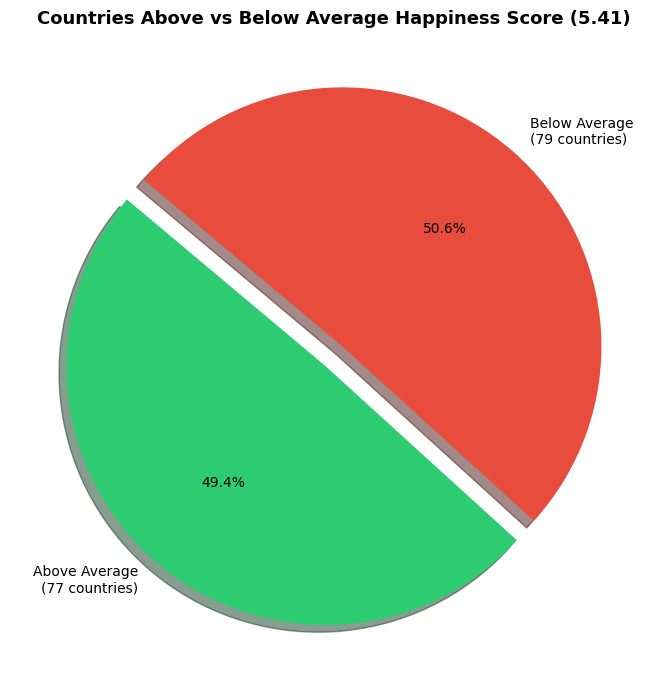

In [53]:
#pie chart
avg = df['score'].mean()
above = (df['score'] >= avg).sum()
below = (df['score'] < avg).sum()

plt.figure(figsize=(7, 7))
plt.pie([above, below],
        labels=[f'Above Average\n({above} countries)', f'Below Average\n({below} countries)'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=140,
        explode=(0.05, 0.05),
        shadow=True)
plt.title(f'Countries Above vs Below Average Happiness Score ({avg:.2f})',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights Report — World Happiness Report 2019
---

### Insight 1: Nordic Countries Have Cracked the Happiness Code
Finland, Denmark, Norway, Iceland, and Sweden occupy the top 5 spots — and it's not a coincidence. These countries share strong social safety nets, low corruption, high trust in government, and excellent healthcare. What's striking is how *consistently* they appear year after year. Happiness here isn't luck — it's a result of deliberate policy choices that prioritize human wellbeing over pure economic growth.

---

### Insight 2: Money Matters — But It's Not Everything
GDP per capita has the strongest correlation with happiness (0.79) — so yes, wealthier nations are generally happier. But here's what's interesting: the relationship isn't perfectly linear. Some high-GDP countries score lower than expected, while some modest-income nations punch above their weight. Money creates the *foundation* for happiness, but it clearly doesn't build the whole house.

---

### Insight 3: The Inequality Gap Is Alarming
The average happiness score of the top 20 wealthiest nations is 6.92 — nearly 3 full points higher than the bottom 20 at 4.03. That 2.89 point gap isn't just a statistic — it represents millions of people living in conditions where basic needs, healthcare, and freedom are out of reach. The data makes one thing painfully clear: where you're born still largely determines how happy you'll be.

---

### Insight 4: Generosity Barely Moves the Needle (And That's Surprising)
Of all the factors measured, generosity had almost zero correlation with happiness (0.076) — the weakest by far. You'd expect that giving cultures would be happier cultures, but the data disagrees. One possible explanation: generosity is measured by charitable donations, which may not capture the everyday kindness and community support that actually makes people feel good.It's a reminder that how we measure something matters enormously.

---

### Insight 5: Most of the World Is Quietly in the Middle
Looking at the histogram, happiness scores follow a fairly normal distribution centered around 5.4 out of 10. There are no huge clusters of extremely happy or deeply miserable nations — most countries sit in a broad middle ground. This suggests that for a majority of the world's population, life is neither great nor terrible — it's somewhere in between, which itself is a call to action for policymakers who want to move the needle upward.

---

### Most Surprising Finding
The near-zero correlation of generosity with happiness genuinely caught me off guard. Intuitively, generous societies feel like they should be happier — but the data tells a different story. It made me question whether the way generosity is measured (monetary donations) truly reflects a culture's warmth and social connectedness. Sometimes the most interesting insight isn't what the data confirms — it's what it challenges.